### Hill Climbing (Dynamic Re-Routing)

Hill Climbing is an uninformed greedy search algorithm that does not compute a full path in advance.

Instead, it moves step-by-step toward the goal, always choosing the neighbor with the lowest heuristic value.

In this Flood Evacuation & Rescue System, Hill Climbing is used for dynamic environments where flood conditions may change during movement, allowing real-time re-routing.

## Advantages
1. Very fast (no full search tree)
2. Low memory usage
3. Works well in dynamic environments

## Limitations
1. Can get stuck in local minima
2. No guarantee of shortest path
3. May loop or fail in complex grids

In [16]:
import sys
import os
import heapq
import random
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

from Environment.grid import *

# Hill Climbing — Single Step (Single Goal)
 
This function decides the **next single move** of the rescue team — it does not plan the whole path at once.
 
For the current cell, it checks all neighbors and picks the one with the **lowest heuristic value** (closest to the goal).
 
If no neighbor is better than the current cell, it means the algorithm is **stuck** (local minimum), and it returns `None`.

In [17]:
# =====================================================
# HILL CLIMBING (STEP-BY-STEP, SINGLE GOAL)
# =====================================================

def hill_climb_step(current, goal):

    neighbors = get_neighbors(current)

    if not neighbors:
        return None

    best_neighbor = None
    best_score = heuristic(current, goal)

    for neighbor in neighbors:

        score = heuristic(neighbor, goal)

        if score < best_score:
            best_score = score
            best_neighbor = neighbor

    return best_neighbor

# Hill Climbing — Single Step (Multi Goal)
 
Since there can be multiple victims on the grid, this version checks the heuristic distance to the **nearest** victim (`heuristic_multi`) instead of a single fixed goal.
 
The logic is the same: move to the neighbor that reduces the distance to the nearest goal the most.

In [18]:
# =====================================================
# HILL CLIMBING (STEP-BY-STEP, MULTI GOAL)
# =====================================================

def hill_climb_step_multi(current, goals):

    neighbors = get_neighbors(current)

    if not neighbors:
        return None

    best_neighbor = None
    best_score = heuristic_multi(current, goals)

    for neighbor in neighbors:

        score = heuristic_multi(neighbor, goals)

        if score < best_score:
            best_score = score
            best_neighbor = neighbor

    return best_neighbor

# Hill Climbing Simulation (Single Goal) — with Flood Spread
 
This function repeatedly calls `hill_climb_step()` to move the rescue team one cell at a time toward the goal.
 
Every 5 steps, `spread_flood()` is called — this simulates the flood **growing dynamically** while the rescue team is moving, making the environment change in real time.
 
The loop stops when:
- The goal is reached ("Goal Reached!")
- No better neighbor is found ("Stuck!")
- `max_steps` is exceeded

In [19]:
# =====================================================
# HILL CLIMBING SIMULATION WITH FLOOD SPREAD (SINGLE GOAL)
# =====================================================

def hill_climbing_simulation(start, goal, max_steps=100):

    current = start
    path = [current]

    for step in range(max_steps):

        if current == goal:
            print("Goal Reached!")
            break

        if step % 5 == 0:
            spread_flood()

        next_cell = hill_climb_step(current, goal)

        if next_cell is None:

            print("Stuck! No passable neighbor closer to goal.")
            break

        current = next_cell
        path.append(current)

    return path

# Hill Climbing Simulation (Multi Goal) — with Flood Spread
 
This is the multi-goal version of the simulation above — used when searching for the **nearest victim** among multiple victims.
 
It works the same way, but checks `current in goal_set` (any victim reached) instead of a single fixed goal, and uses `hill_climb_step_multi()` for movement decisions.
 
Flood spreading every 5 steps simulates a **dynamic, worsening flood situation** during the rescue team's movement.

In [20]:
# =====================================================
# HILL CLIMBING SIMULATION WITH FLOOD SPREAD (MULTI GOAL)
# =====================================================

def hill_climbing_simulation_multi(start, goals, max_steps=100):

    current = start
    path = [current]
    goal_set = set(goals)

    for step in range(max_steps):

        if current in goal_set:
            print("Goal Reached!", current)
            break

        if step % 5 == 0:
            spread_flood()

        next_cell = hill_climb_step_multi(current, goals)

        if next_cell is None:

            print("Stuck! No passable neighbor closer to goal.")
            break

        current = next_cell
        path.append(current)

    return path

# Complete Rescue Operation using Hill Climbing
 
The rescue team begins from the top-left corner of the grid.
 
**Step 1:** Move greedily from the start position toward the **nearest victim** (multi-goal Hill Climbing), with flood spreading dynamically along the way.
 
**Step 2:** From the victim's location, move greedily toward the **shelter** (single-goal Hill Climbing).
 
Both paths are combined to form the complete rescue path.
 
Rescue Team → Victim → Shelter (Hill Climbing, Dynamic Re-Routing)

In [21]:
# =====================================================
# TEST HILL CLIMBING (MULTI GOAL - START TO VICTIM TO SHELTER)
# =====================================================

start = (0, 0)

# Step 1: Start se nearest victim tak
hill_path_to_victim = hill_climbing_simulation_multi(start, victims)

found_victim_hc = hill_path_to_victim[-1]

# Step 2: Victim se shelter tak (single goal)
hill_path_to_shelter = hill_climbing_simulation(found_victim_hc, shelter)

if hill_path_to_victim and hill_path_to_shelter:

    full_path_hc = hill_path_to_victim + hill_path_to_shelter[1:]

    print("Nearest Victim (Hill Climbing):", found_victim_hc)
    print("Hill Climbing Path to Victim:", len(hill_path_to_victim)-1, "steps")
    print("Hill Climbing Path to Shelter:", len(hill_path_to_shelter)-1, "steps")
    print("Hill Climbing Total Rescue Path:", len(full_path_hc)-1, "steps")

else:

    print("No valid rescue path found.")

Goal Reached! (18, 6)
Goal Reached!
Nearest Victim (Hill Climbing): (18, 6)
Hill Climbing Path to Victim: 24 steps
Hill Climbing Path to Shelter: 12 steps
Hill Climbing Total Rescue Path: 36 steps


# Stage 1: Initial Grid
 
Before running the simulation, the initial state of the grid is displayed — showing roads, buildings, flood cells, victims, and the shelter.

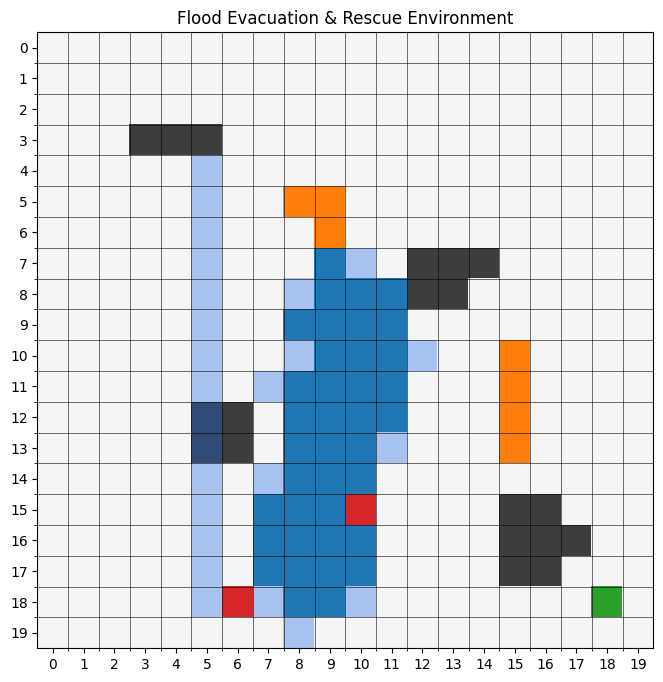

In [22]:
# =====================================================
# STAGE 1: INITIAL GRID
# =====================================================
from Environment.grid import *

display_grid(save_image=False)

# Stage 2: Hill Climbing Path to Victim
 
This function visualizes the path taken by the rescue team from the start position to the nearest victim.
 
The risky/flooded cells are shown with a light blue overlay, and the path taken by Hill Climbing is highlighted in **yellow**.
 
Because Hill Climbing moves step-by-step and the flood is spreading dynamically, this path may not be the shortest — it reflects real-time decision-making under changing conditions.

In [23]:
# =====================================================
# STAGE 2: HILL CLIMBING PATH TO VICTIM
# =====================================================

def display_hill_climb_path_to_victim(path, save_image=True):

    colors = [
        "#f5f5f5",  # ROAD
        "#3d3d3d",  # BUILDING
        "#1f77b4",  # FLOOD
        "#ff7f0e",  # BLOCKED
        "#d62728",  # VICTIM
        "#2ca02c"   # SHELTER
    ]

    cmap = ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(8,8))

    ax.imshow(
        cell_type,
        cmap=cmap,
        vmin=0,
        vmax=5
    )

    overlay = np.zeros((ROWS, COLS, 4))

    for r in range(ROWS):
        for c in range(COLS):

            if (
                RISKY_THRESHOLD
                <
                water_level[r][c]
                <=
                FLOOD_THRESHOLD
            ):

                overlay[r][c] = [
                    0.1,
                    0.4,
                    0.9,
                    0.35
                ]

    ax.imshow(overlay)

    for r, c in path:

        ax.add_patch(
            plt.Rectangle(
                (c, r),
                1,
                1,
                color="yellow",
                alpha=0.4
            )
        )

    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))

    ax.set_xticks(
        [x - 0.5 for x in range(1, COLS)],
        minor=True
    )

    ax.set_yticks(
        [y - 0.5 for y in range(1, ROWS)],
        minor=True
    )

    ax.grid(
        which="minor",
        color="black",
        linewidth=0.4
    )

    ax.set_title(
        "Stage 2: Victim Found (Hill Climbing Path)"
    )

    if save_image:

        plt.savefig(
            "../images/hill_climb_stage2_victim_found.png",
            bbox_inches="tight"
        )

        print(
            "\nImage Saved: hill_climb_stage2_victim_found.png"
        )

    plt.show()


Image Saved: hill_climb_stage2_victim_found.png


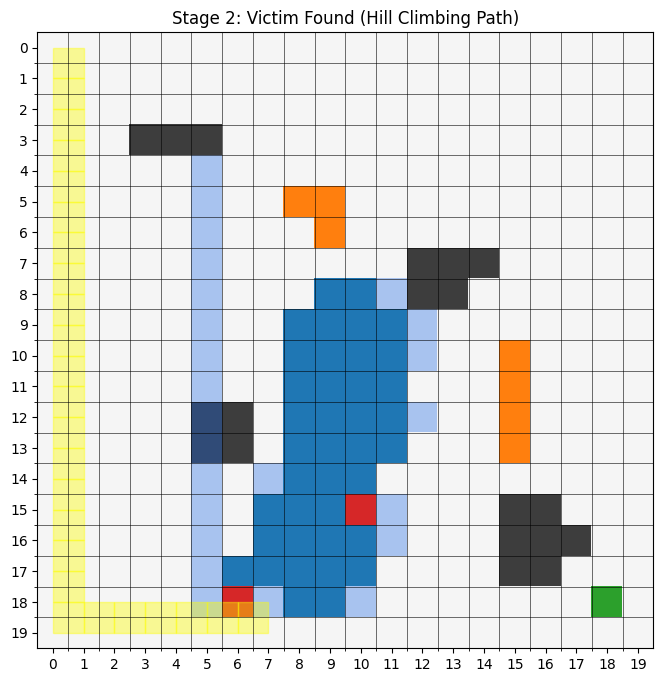

In [12]:
display_hill_climb_path_to_victim(hill_path_to_victim)

# Victim to Shelter — Hill Climbing
 
From the victim's location, Hill Climbing is run again to move greedily toward the shelter.
 
The two paths (Start → Victim and Victim → Shelter) are combined into `full_path_hc`.
 
A check is performed to confirm whether the shelter was actually reached, or whether the algorithm got **stuck** somewhere along the way (a known limitation of Hill Climbing).

In [24]:
# =====================================================
# TEST HILL CLIMBING (VICTIM TO SHELTER)
# =====================================================

hill_path_to_shelter = hill_climbing_simulation(found_victim_hc, shelter)

full_path_hc = hill_path_to_victim + hill_path_to_shelter[1:]

print("\nFULL RESCUE PATH (Hill Climbing):")
print(full_path_hc)

if full_path_hc[-1] == shelter:
    print("\nShelter successfully reached!")
else:
    print("\nStuck before reaching shelter. Stopped at:", full_path_hc[-1])

print("\nTotal Steps:", len(full_path_hc)-1)

Goal Reached!

FULL RESCUE PATH (Hill Climbing):
[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0), (8, 0), (9, 0), (10, 0), (11, 0), (12, 0), (13, 0), (14, 0), (15, 0), (16, 0), (17, 0), (18, 0), (18, 1), (18, 2), (18, 3), (18, 4), (18, 5), (18, 6), (18, 7), (18, 8), (18, 9), (18, 10), (18, 11), (18, 12), (18, 13), (18, 14), (18, 15), (18, 16), (18, 17), (18, 18)]

Shelter successfully reached!

Total Steps: 36


# Stage 3: Full Rescue Path (Victim to Shelter)
 
This function visualizes the complete rescue journey — from the rescue team's start position, through the victim, to the shelter — highlighted in **green** over the grid.
 
The risky/flooded overlay is shown again, so you can visually judge how the Hill Climbing path interacts with the dynamically spreading flood.

In [25]:
# =====================================================
# STAGE 3: FULL RESCUE PATH (VICTIM TO SHELTER) - HILL CLIMBING
# =====================================================

def display_hill_climb_full_rescue_path(full_path, save_image=True):

    colors = [
        "#f5f5f5",  # ROAD
        "#3d3d3d",  # BUILDING
        "#1f77b4",  # FLOOD
        "#ff7f0e",  # BLOCKED
        "#d62728",  # VICTIM
        "#2ca02c"   # SHELTER
    ]

    cmap = ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(8,8))

    ax.imshow(
        cell_type,
        cmap=cmap,
        vmin=0,
        vmax=5
    )

    overlay = np.zeros((ROWS, COLS, 4))

    for r in range(ROWS):
        for c in range(COLS):

            if (
                RISKY_THRESHOLD
                <
                water_level[r][c]
                <=
                FLOOD_THRESHOLD
            ):

                overlay[r][c] = [
                    0.1,
                    0.4,
                    0.9,
                    0.35
                ]

    ax.imshow(overlay)

    for r, c in full_path:

        ax.add_patch(
            plt.Rectangle(
                (c, r),
                1,
                1,
                color="green",
                alpha=0.4
            )
        )

    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))

    ax.set_xticks(
        [x - 0.5 for x in range(1, COLS)],
        minor=True
    )

    ax.set_yticks(
        [y - 0.5 for y in range(1, ROWS)],
        minor=True
    )

    ax.grid(
        which="minor",
        color="black",
        linewidth=0.4
    )

    ax.set_title(
        "Stage 3: Full Rescue Completed (Hill Climbing)"
    )

    if save_image:

        plt.savefig(
            "../images/hill_climb_stage3_full_rescue.png",
            bbox_inches="tight"
        )

        print(
            "\nImage Saved: hill_climb_stage3_full_rescue.png"
        )

    plt.show()


Image Saved: hill_climb_stage3_full_rescue.png


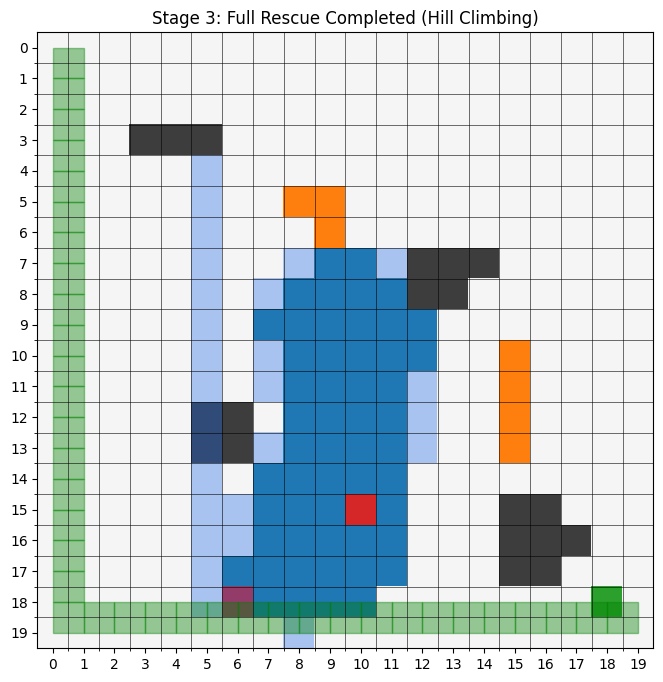

In [12]:
display_hill_climb_full_rescue_path(full_path_hc)

In [26]:
reset_grid()